In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
data = "C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/bank-full.csv"
df = pd.read_csv(data, sep=';')

# Save the properly separated dataframe to a new standard csv file (comma-delimited)
df.to_csv('bank_separated.csv', index=False)

# Display the first few rows to verify
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [45]:
df.shape

(45211, 17)

In [46]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 1 columns):
 #   Column                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                --------------  ----- 
 0   age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"  45211 non-null  object
dtypes: object(1)
memory usage: 353.3+ KB


In [47]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [37]:
df.isnull().sum()

age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"    0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [50]:
df['y_numeric'] = df['y'].map({'no': 0, 'yes': 1})
# Keep 'education' as text for plots, but create 'education_rank' for the model
edu_map = {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
df['education_rank'] = df['education'].map(edu_map)

# Keep original columns and create encoded versions for the model
df['job_code'] = df['job'].astype('category').cat.codes
df['marital_code'] = df['marital'].astype('category').cat.codes

# NOW:
# Use df['job'] for your Boxplots (so you see the names)
# Use df['job_code'] for your Heatmap and Random Forest

In [51]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,y_numeric,education_rank,job_code,marital_code
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,-1,0,unknown,no,0,3,4,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,151,1,-1,0,unknown,no,0,2,9,2
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,76,1,-1,0,unknown,no,0,2,2,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,92,1,-1,0,unknown,no,0,0,1,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,198,1,-1,0,unknown,no,0,0,11,2


In [52]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'y_numeric', 'education_rank', 'job_code',
       'marital_code'],
      dtype='object')

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
balance           0
housing           0
loan              0
contact           0
day               0
month             0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
y                 0
y_numeric         0
education_rank    0
job_code          0
marital_code      0
dtype: int64

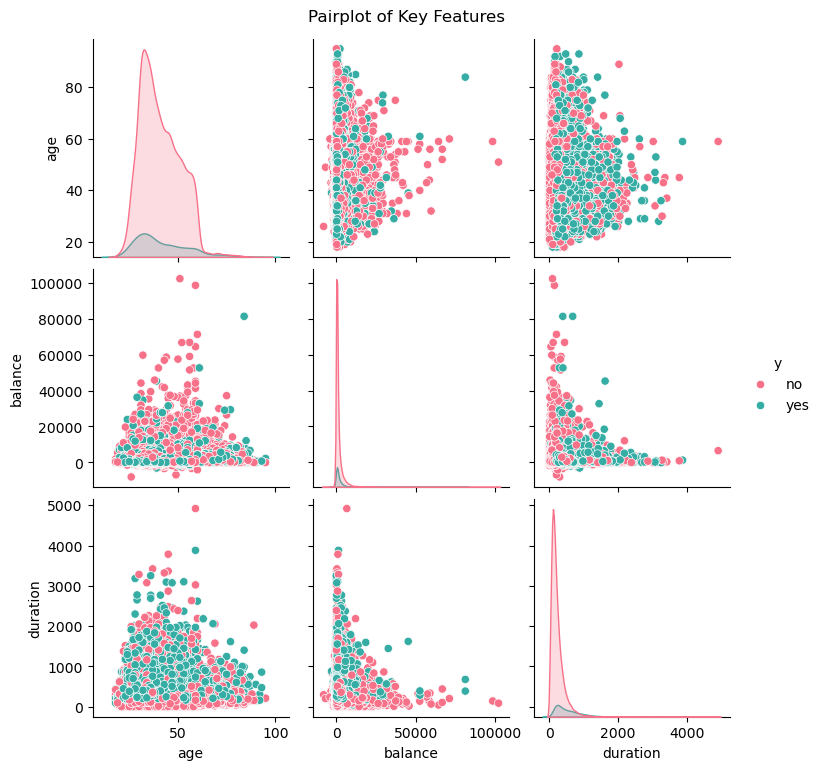

In [55]:
subset_cols = ['age', 'balance', 'duration', 'y']
sns.pairplot(df[subset_cols], hue='y', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/graphs/pairplot.png")
plt.show()

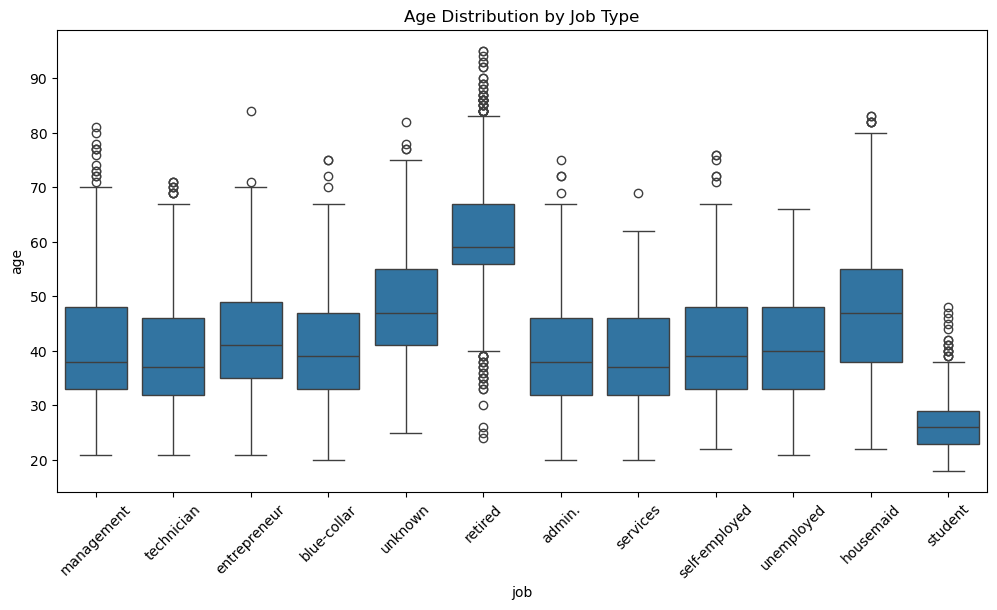

In [58]:
plt.figure(figsize=(12, 6))
# Using 'job' (text) and 'age' (numeric)
sns.boxplot(x='job', y='age', data=df)
plt.xticks(rotation=45) # Rotate names so they don't overlap
plt.title('Age Distribution by Job Type')
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/graphs/BoxPlot.png")
plt.show()

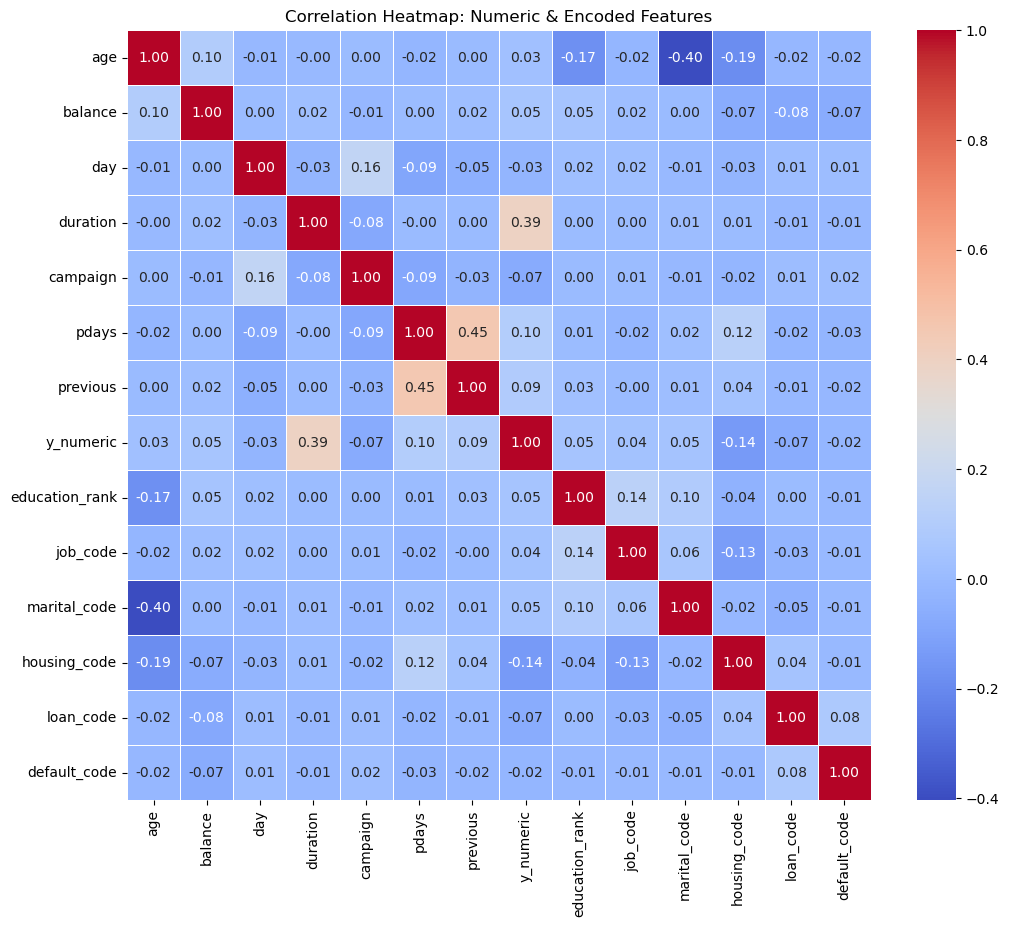

In [61]:
# Map Binary columns (housing, loan, default)
binary_map = {'yes': 1, 'no': 0}
df['housing_code'] = df['housing'].map(binary_map)
df['loan_code'] = df['loan'].map(binary_map)
df['default_code'] = df['default'].map(binary_map)

# 3. Select only the numeric columns for the correlation matrix
heatmap_cols = [
    'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
    'y_numeric', 'education_rank', 'job_code', 'marital_code', 
    'housing_code', 'loan_code', 'default_code'
]

# Calculate the correlation
corr_matrix = df[heatmap_cols].corr()

# 4. Generate the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Numeric & Encoded Features')
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/graphs/Heatmap.png")
plt.show()

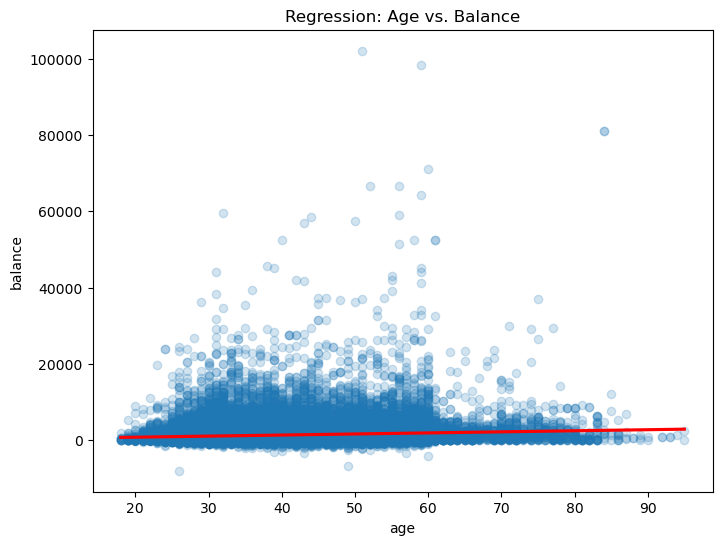

In [59]:
plt.figure(figsize=(8, 6))
# Using numeric columns
sns.regplot(x='age', y='balance', data=df, 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Regression: Age vs. Balance')
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/graphs/Regression.png")
plt.show()

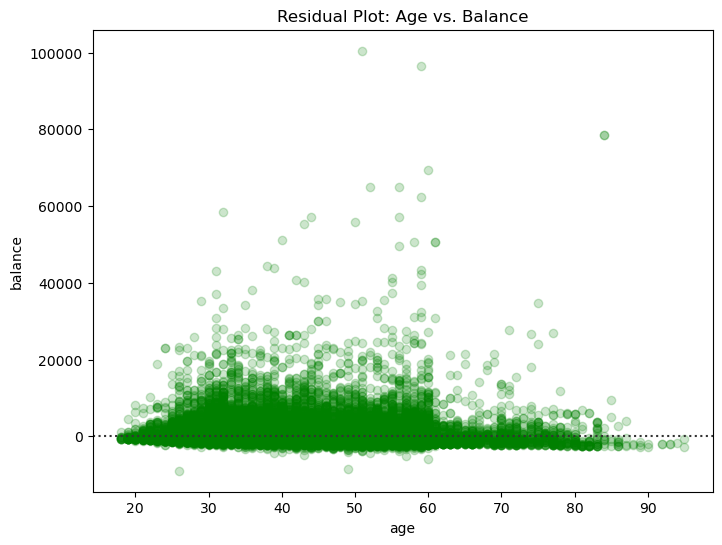

In [60]:
plt.figure(figsize=(8, 6))
# Checking the residuals of the Age/Balance relationship
sns.residplot(x='age', y='balance', data=df, color='green', scatter_kws={'alpha':0.2})
plt.title('Residual Plot: Age vs. Balance')
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/graphs/Residual.png")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12200\4189636472.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='viridis')


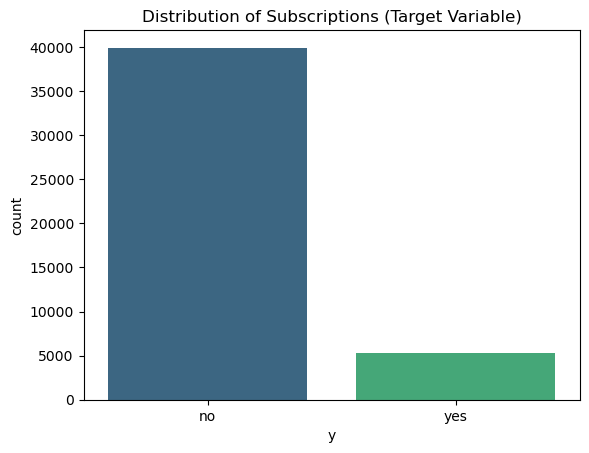

In [62]:
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribution of Subscriptions (Target Variable)')
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/graphs/Distribution of Subscriptions (Target Variable).png")
plt.show()

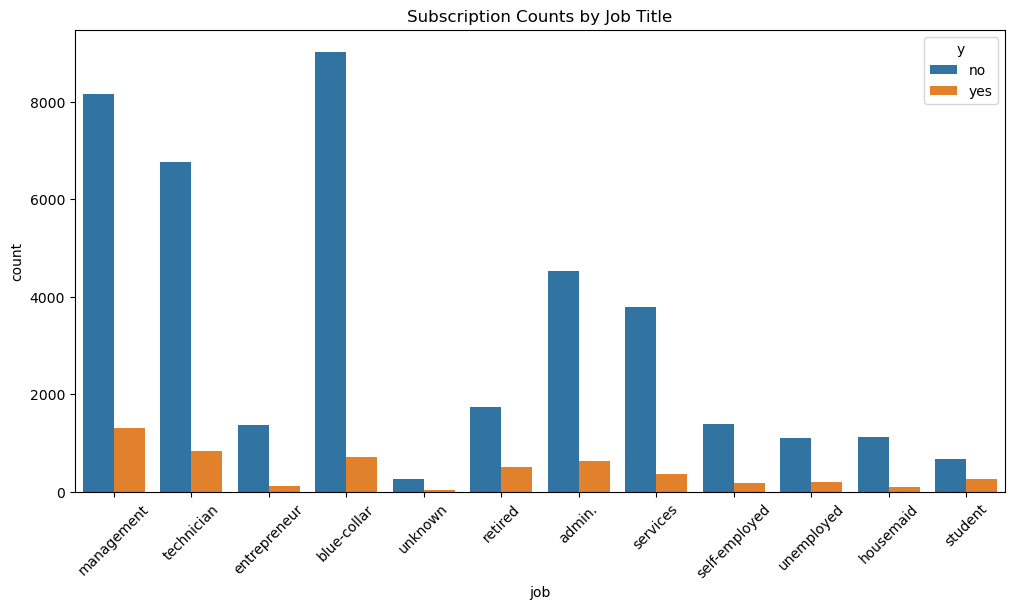

In [63]:
plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Subscription Counts by Job Title')
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/graphs/Subscription Counts by Job Title.png")
plt.show()

In [64]:
month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 
             'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}
df['month_num'] = df['month'].map(month_map)

In [66]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,poutcome,y,y_numeric,education_rank,job_code,marital_code,housing_code,loan_code,default_code,month_num
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,unknown,no,0,3,4,1,1,0,0,5
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,unknown,no,0,2,9,2,1,0,0,5
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,unknown,no,0,2,2,1,1,1,0,5
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,unknown,no,0,0,1,1,1,0,0,5
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,unknown,no,0,0,11,2,0,0,0,5


In [67]:
for col in ['contact', 'poutcome']:
    df[col + '_code'] = df[col].astype('category').cat.codes

In [68]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,y_numeric,education_rank,job_code,marital_code,housing_code,loan_code,default_code,month_num,contact_code,poutcome_code
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,0,3,4,1,1,0,0,5,2,3
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,0,2,9,2,1,0,0,5,2,3
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,0,2,2,1,1,1,0,5,2,3
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,0,0,1,1,1,0,0,5,2,3
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,0,0,11,2,0,0,0,5,2,3


Accuracy: 0.9053

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.40      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043



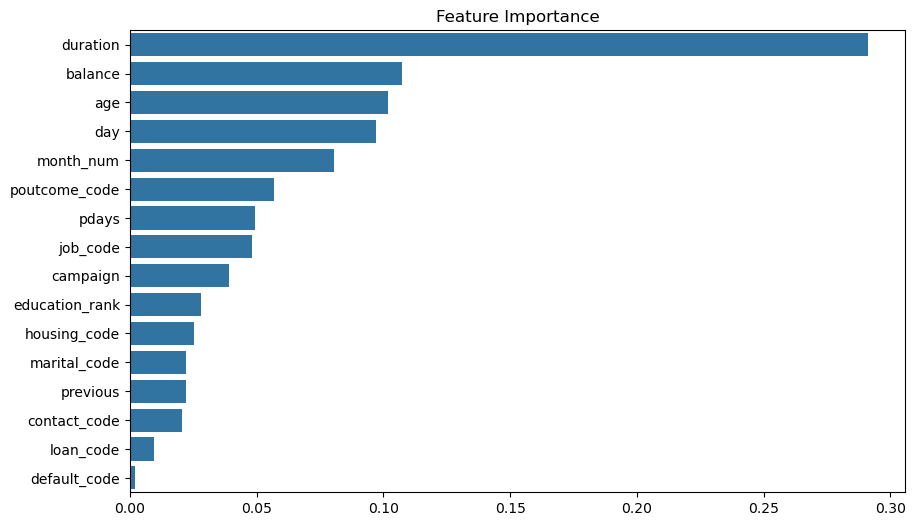

In [71]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

feature_cols = [
    'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
    'education_rank', 'month_num', 'default_code', 'housing_code', 'loan_code',
    'job_code', 'marital_code', 'contact_code', 'poutcome_code'
]
X = df[feature_cols]
y = df['y_numeric']

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train the Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Plot Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[feature_cols[i] for i in indices])
plt.title('Feature Importance')
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/4 28th_Logistic+Regresssion_Project7/4. Logistic Regresssion/graphs/Feature Importance.png")
plt.show()